# Machine Learning Introduction
## Проект: Предсказание арендной цены квартир (Two Sigma Connect)

## 1. Ответы на вопросы

**1.1 Выведите аналитическое решение задачи регрессии. Используйте векторную форму уравнения.**

Обозначения: $X$ — матрица объекты-признаки размера $N \times (D{+}1)$ (первый столбец из единиц — для смещения $b$), $w$ — вектор параметров размера $(D{+}1)$, $y$ — вектор целевых значений.

Модель: $\hat{y} = Xw$.

Функция потерь (MSE без множителя $\frac{1}{N}$ — он не влияет на точку минимума):

$$L(w) = |y - Xw|_2^2 = (y - Xw)^T (y - Xw) = y^T y - 2 w^T X^T y + w^T X^T X w$$

Берём градиент по $w$ и приравниваем к нулю:

$$\nabla_w L = -2 X^T y + 2 X^T X w = 0$$

Получаем нормальные уравнения:

$$X^T X w = X^T y$$

Откуда аналитическое решение (метод наименьших квадратов, OLS):

$$\boxed{,w = (X^T X)^{-1} X^T y,}$$

Решение существует при условии, что $X^T X$ обратима (признаки линейно независимы, $N \ge D{+}1$). Член $(X^TX)^{-1}X^T$ — это псевдообратная матрица Мура–Пенроуза.


**1.2 Что меняется в решении, когда в функцию потерь добавляются L1 и L2 регуляризации.**

L2 (Ridge). Добавляем $\lambda |w|_2^2$:

$$L(w) = |y - Xw|_2^2 + \lambda |w|_2^2$$

Градиент: $-2X^Ty + 2X^TXw + 2\lambda w = 0$, откуда снова есть замкнутое аналитическое решение:

$$\boxed{,w = (X^T X + \lambda I)^{-1} X^T y,}$$

Что изменилось: к диагонали добавляется $\lambda I$. Это делает матрицу всегда обратимой и лучше обусловленной (решается проблема мультиколлинеарности и случая $D > N$), а веса «стягиваются» к нулю (но не становятся точно нулевыми). Обычно смещение $b$ не регуляризуют (соответствующий элемент в $\lambda I$ = 0).

L1 (Lasso). Добавляем $\lambda |w|_1$:

$$L(w) = |y - Xw|_2^2 + \lambda |w|_1$$

Норма $|w|_1$ недифференцируема в нуле, поэтому замкнутого аналитического решения нет. В производной появляется субградиент $\lambda \cdot \mathrm{sign}(w)$, и задачу решают итеративно: координатный спуск, проксимальный/субградиентный спуск, LARS. Для отдельной координаты решение даёт оператор мягкого порога (soft-thresholding):

$$w_j = \mathrm{sign}(z_j),\max(0,\ |z_j| - \lambda)$$

ElasticNet = комбинация обоих штрафов: $\lambda_1|w|_1 + \lambda_2|w|_2^2$.


**1.3 Объясните, почему L1-регуляризация часто используется для отбора признаков. Почему после подгонки модели многие веса равны 0?**

Геометрическое объяснение. Регуляризация эквивалентна минимизации MSE при ограничении на норму весов. Область ограничения для L1 ($|w|_1 \le t$) — это ромб/октаэдр с вершинами на осях координат, а для L2 — круг/шар. Линии уровня функции потерь (эллипсы) касаются области ограничения: для ромба касание с большой вероятностью происходит в вершине, где часть координат равна нулю. У круга касание может быть в любой точке и почти никогда не попадает точно на ось.

Аналитическое объяснение. Из формулы мягкого порога видно: если корреляция признака с остатком по модулю меньше порога $\lambda$ ($|z_j| < \lambda$), то $w_j$ становится точно равным 0. То есть L1 буквально обнуляет «слабые» признаки.

В отличие от L2, которая уменьшает веса пропорционально, но никогда не делает их строго нулевыми. Поэтому решение Lasso разреженное (sparse) — ненулевые веса остаются только у важных признаков, что и есть автоматический отбор признаков.

**1.4 Объясните, как можно использовать те же модели (линейная регрессия, Ridge и т.д.), но сделать возможной подгонку нелинейных зависимостей.**

Ключевая идея: модель линейна по параметрам $w$, но не обязана быть линейной по исходным признакам $x$. Заменяем входы на нелинейные функции-преобразования (базисные функции) $\phi(x)$:

$$\hat{y} = w^T \phi(x)$$

Тогда всё устройство обучения (нормальные уравнения, Ridge/Lasso, градиентный спуск) остаётся прежним — меняется только матрица признаков.

Примеры $\phi(x)$:

Полиномиальные признаки: $\phi(x) = [1,\ x,\ x^2,\ \dots,\ x^d]$ — полиномиальная регрессия.
Произведения признаков (взаимодействия): $x_i \cdot x_j$.
Нелинейные преобразования: $\log x$, $\sqrt{x}$, $\sin x$.
RBF / гауссовы / сплайн-базисы.

## 2. Введение — выполните всю подготовительную работу из предыдущего урока

### 2.1 Импорт библиотек

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# === Настройки отображения ===
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.style.use('seaborn-v0_8-whitegrid')

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

print("Все библиотеки успешно импортированы!")


Все библиотеки успешно импортированы!


### 2.2 Прочитайте обучающую и тестовую части.

In [18]:
df_train = pd.read_json("data/train.json")
df_test = pd.read_json("data/test.json")

print("Train:", df_train.shape)
print("Test: ", df_test.shape)

df_train.head()

Train: (49352, 15)
Test:  (74659, 14)


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


## 3. Вводный анализ данных, часть 2

### 3.1 Генерация дополнительных признаков.

In [19]:
df_train['features'].head(10)

4     [Dining Room, Pre-War, Laundry in Building, Di...
6     [Doorman, Elevator, Laundry in Building, Dishw...
9     [Doorman, Elevator, Laundry in Building, Laund...
10                                                   []
15    [Doorman, Elevator, Fitness Center, Laundry in...
16    [Doorman, Elevator, Loft, Dishwasher, Hardwood...
18    [Fireplace, Laundry in Unit, Dishwasher, Hardw...
19    [Elevator, Laundry in Building, Dishwasher, Ha...
23                                    [Hardwood Floors]
32                         [Cats Allowed, Dogs Allowed]
Name: features, dtype: object

### 3.2 Удалите неиспользуемые символы ([,], ', " и пробел) из столбца.

In [20]:
def clean_features(lst):
    """Список особенностей → строка → убираем [ ] ' " и пробелы → разбиваем по запятой."""
    s = str(lst)
    for ch in ['[', ']', "'", '"', ' ']:
        s = s.replace(ch, '')
    return [x for x in s.split(',') if x]

# Проверим на первых строках
df_train['features'].head(10).apply(clean_features)

4     [DiningRoom, Pre-War, LaundryinBuilding, Dishw...
6     [Doorman, Elevator, LaundryinBuilding, Dishwas...
9     [Doorman, Elevator, LaundryinBuilding, Laundry...
10                                                   []
15    [Doorman, Elevator, FitnessCenter, LaundryinBu...
16    [Doorman, Elevator, Loft, Dishwasher, Hardwood...
18    [Fireplace, LaundryinUnit, Dishwasher, Hardwoo...
19    [Elevator, LaundryinBuilding, Dishwasher, Hard...
23                                     [HardwoodFloors]
32                           [CatsAllowed, DogsAllowed]
Name: features, dtype: object

### 3.3 Получите все значения в каждом списке и соберите результат в один огромный список для всего набора данных. Вы можете использовать DataFrame.iterrows().

In [21]:
all_features = []
for _, row in df_train.iterrows():
    all_features.extend(clean_features(row['features']))

print("Всего значений в списке:", len(all_features))
all_features[:20]

Всего значений в списке: 267906


['DiningRoom',
 'Pre-War',
 'LaundryinBuilding',
 'Dishwasher',
 'HardwoodFloors',
 'DogsAllowed',
 'CatsAllowed',
 'Doorman',
 'Elevator',
 'LaundryinBuilding',
 'Dishwasher',
 'HardwoodFloors',
 'NoFee',
 'Doorman',
 'Elevator',
 'LaundryinBuilding',
 'LaundryinUnit',
 'Dishwasher',
 'HardwoodFloors',
 'Doorman']

### 3.4 Сколько уникальных значений содержит результирующий список?

In [22]:
print("Всего значений:", len(all_features))
print("Уникальных значений:", len(set(all_features)))

Всего значений: 267906
Уникальных значений: 1546


### 3.5-6 Подсчитайте самые популярные функции из нашего огромного списка и возьмите топ-20 на данный момент.

In [23]:
from collections import Counter

# Counter автоматически считает, сколько раз встречается каждое значение
counter = Counter(all_features)

# Топ-20 самых частых особенностей
top20 = [name for name, _ in counter.most_common(20)]
print(top20)

['Elevator', 'CatsAllowed', 'HardwoodFloors', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace']


### 3.8 Теперь создайте 20 новых признаков на основе топ-20 значений: 1, если значение есть в столбце «Feature», иначе 0.


In [24]:
for df in [df_train, df_test]:
    # для каждой строки — множество её очищенных особенностей (быстрая проверка вхождения)
    cleaned = df['features'].apply(lambda lst: set(clean_features(lst)))
    for feat in top20:
        df[feat] = cleaned.apply(lambda s: 1 if feat in s else 0)

df_train[top20].head()

,Elevator,CatsAllowed,HardwoodFloors,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,FitnessCenter,Pre-War,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,0,1,1,1,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0
6,1,0,1,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
9,1,0,1,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0
10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
15,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0


### 3.9 Расширьте наш набор признаков значениями 'bathrooms', 'bedrooms' и создайте специальную переменную feature_list со всеми именами признаков. Теперь у нас 22 значения. Все модели должны обучаться на этих 22 признаках.


In [25]:
feature_list = top20 + ['bathrooms', 'bedrooms']

print("Количество признаков:", len(feature_list))
print(feature_list)

Количество признаков: 22
['Elevator', 'CatsAllowed', 'HardwoodFloors', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace', 'bathrooms', 'bedrooms']


## 4. Реализация моделей — линейная регрессия

### 4.1 Реализуйте класс Python для алгоритма линейной регрессии с двумя базовыми методами — fit и predict. Используйте стохастический градиентный спуск (SGD) для нахождения оптимальных весов модели. Для лучшего понимания мы рекомендуем реализовать отдельные версии алгоритма с аналитическим решением и нестохастическим градиентным спуском под капотом.

In [26]:
# === Матрицы признаков X и таргет y на 22 признаках ===
target = 'price'

# Убираем выбросы по 1-му и 99-му перцентилям цены (как в предыдущем уроке).
# Порог считаем по train и применяем к обоим наборам.
lo, hi = df_train[target].quantile(0.01), df_train[target].quantile(0.99)
df_train = df_train[(df_train[target] >= lo) & (df_train[target] <= hi)].reset_index(drop=True)
df_test  = df_test[(df_test[target]  >= lo) & (df_test[target]  <= hi)].reset_index(drop=True)

# feature_list = top20 + ['bathrooms', 'bedrooms']  -> 22 признака
X_train = df_train[feature_list].values.astype(float)
y_train = df_train[target].values.astype(float)
X_test  = df_test[feature_list].values.astype(float)
y_test  = df_test[target].values.astype(float)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test: ", X_test.shape,  "| y_test: ", y_test.shape)


X_train: (48379, 22) | y_train: (48379,)
X_test:  (73255, 22) | y_test:  (73255,)


In [27]:
class MyLinearRegression:
    """
    Линейная регрессия с тремя взаимозаменяемыми способами обучения:
      method='sgd'      — стохастический градиентный спуск (требуется в задании),
      method='gd'       — обычный (батч) градиентный спуск,
      method='analytic' — аналитическое решение (нормальные уравнения).

    Базовый интерфейс — fit / predict.
    """

    def __init__(self, method='sgd', lr=0.01, n_epochs=50, batch_size=1,
                 standardize=True, random_state=42, verbose=False):
        self.method = method            # способ обучения
        self.lr = lr                    # скорость обучения (learning rate)
        self.n_epochs = n_epochs        # число проходов по выборке
        self.batch_size = batch_size    # размер мини-батча для sgd (1 = чистый SGD)
        self.standardize = standardize  # внутренняя стандартизация признаков
        self.random_state = random_state
        self.verbose = verbose


    # --- стандартизация + добавление столбца единиц для смещения b ---
    def _design_matrix(self, X):
        X = np.asarray(X, dtype=float)
        if self.standardize:
            X = (X - self.mu_) / self.sigma_
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])          # [1, x1, x2, ..., x22]


    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()

        # параметры стандартизации запоминаем по train
        self.mu_ = X.mean(axis=0)
        self.sigma_ = X.std(axis=0)
        self.sigma_[self.sigma_ == 0] = 1.0  # защита от деления на ноль

        Xb = self._design_matrix(X)          # (n, d+1)
        n, d = Xb.shape

        # --- 1) аналитическое решение: w = (XᵀX)⁻¹ Xᵀy ---
        if self.method == 'analytic':
            self.w_ = np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ y
            return self

        # --- 2) и 3) градиентный спуск ---
        rng = np.random.RandomState(self.random_state)  # делает SGD детерминированным
        w = np.zeros(d)
        w[0] = y.mean()                       # старт смещения с среднего ускоряет сходимость

        bs = n if self.method == 'gd' else self.batch_size


        for epoch in range(self.n_epochs):
            # sgd: каждый эпох перемешиваем объекты; gd: один градиент по всей выборке
            order = rng.permutation(n) if self.method == 'sgd' else np.arange(n)

            for start in range(0, n, bs):
                idx = order[start:start + bs]
                xb, yb = Xb[idx], y[idx]
                # градиент MSE по w:  (2/m) * Xbᵀ (Xb·w - y)
                grad = (2.0 / len(idx)) * xb.T @ (xb @ w - yb)
                w = w - self.lr * grad

            if self.verbose and epoch % 10 == 0:
                mse = np.mean((Xb @ w - y) ** 2)
                print(f"epoch {epoch:3d} | MSE = {mse:,.0f}")

        self.w_ = w
        return self

    def predict(self, X):
        return self._design_matrix(X) @ self.w_


In [28]:
for method in ['analytic', 'gd', 'sgd']:
    model = MyLinearRegression(method=method).fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = np.mean(np.abs(y_test - pred))
    print(f"{method:9s} | test MAE = {mae:,.1f}")


analytic  | test MAE = 717.1
gd        | test MAE = 744.8
sgd       | test MAE = 872.7


### 4.2 Что такое детерминированная модель? Сделайте SGD детерминированным.

In [29]:
# 1) Один и тот же random_state -> результат идентичен (модель детерминирована)
m1 = MyLinearRegression(method='sgd', random_state=42).fit(X_train, y_train)
m2 = MyLinearRegression(method='sgd', random_state=42).fit(X_train, y_train)

print("Веса полностью совпадают:", np.array_equal(m1.w_, m2.w_))
print("MAE m1:", round(np.mean(np.abs(y_test - m1.predict(X_test))), 4))
print("MAE m2:", round(np.mean(np.abs(y_test - m2.predict(X_test))), 4))

# 2) Без фиксированного зерна (random_state=None) -> каждый запуск разный (стохастика)
a = MyLinearRegression(method='sgd', random_state=None).fit(X_train, y_train)
b = MyLinearRegression(method='sgd', random_state=None).fit(X_train, y_train)

print("\nБез зерна веса совпадают:", np.array_equal(a.w_, b.w_))
print("MAE a:", round(np.mean(np.abs(y_test - a.predict(X_test))), 4))
print("MAE b:", round(np.mean(np.abs(y_test - b.predict(X_test))), 4))


Веса полностью совпадают: True
MAE m1: 872.6941
MAE m2: 872.6941

Без зерна веса совпадают: False
MAE a: 849.6873
MAE b: 884.1932


Детерминированная модель при одинаковых данных и гиперпараметрах всегда выдаёт идентичный результат. SGD недетерминирован из-за случайного перемешивания объектов каждую эпоху. Чтобы сделать его детерминированным, мы фиксируем зерно генератора (random_state=42) и проводим всё перемешивание через локальный np.random.RandomState(random_state). Тогда последовательность перемешиваний воспроизводима, и обучение даёт одни и те же веса при каждом запуске.

### 4.3 Определите коэффициент R-квадрат (R2) и реализуйте функцию для его вычисления.

In [30]:
def r2_score_custom(y_true, y_pred):
    """Коэффициент детерминации R² = 1 - SS_res / SS_tot."""
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    ss_res = np.sum((y_true - y_pred) ** 2)            # ошибка модели
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)     # разброс вокруг среднего
    return 1 - ss_res / ss_tot


model = MyLinearRegression(method='analytic').fit(X_train, y_train)
pred  = model.predict(X_test)

print("Мой R²:    ", round(r2_score_custom(y_test, pred), 6))
print("sklearn R²:", round(r2_score(y_test, pred), 6))


Мой R²:     0.404928
sklearn R²: 0.404928


### 4.4 Сделайте предсказания вашим алгоритмом и оцените модель метриками MAE, RMSE и R2.

In [31]:
# Обучаем нашу модель (SGD — основной алгоритм по заданию)
model = MyLinearRegression(method='sgd').fit(X_train, y_train)

# Предсказания на обеих выборках
pred_train = model.predict(X_train)
pred_test  = model.predict(X_test)

# Считаем три метрики на train и на test
print("Метрика |      train |       test")
print("-" * 36)
print(f"MAE     | {mean_absolute_error(y_train, pred_train):10.2f} | {mean_absolute_error(y_test, pred_test):10.2f}")
print(f"RMSE    | {root_mean_squared_error(y_train, pred_train):10.2f} | {root_mean_squared_error(y_test, pred_test):10.2f}")
print(f"R2      | {r2_score_custom(y_train, pred_train):10.4f} | {r2_score_custom(y_test, pred_test):10.4f}")


Метрика |      train |       test
------------------------------------
MAE     |     867.66 |     872.69
RMSE    |    1224.76 |    1390.89
R2      |     0.4123 |     0.2351


In [34]:
def evaluate(model, X_train, y_train, X_test, y_test):
    """Возвращает MAE, RMSE, R2 на train и test в виде словаря."""
    pred_tr, pred_te = model.predict(X_train), model.predict(X_test)
    return {
        'MAE_train':  mean_absolute_error(y_train, pred_tr),
        'MAE_test':   mean_absolute_error(y_test, pred_te),
        'RMSE_train': root_mean_squared_error(y_train, pred_tr),
        'RMSE_test':  root_mean_squared_error(y_test, pred_te),
        'R2_train':   r2_score_custom(y_train, pred_tr),
        'R2_test':    r2_score_custom(y_test, pred_te),
    }

evaluate(model, X_train, y_train, X_test, y_test)


{'MAE_train': 867.6564189580079,
 'MAE_test': 872.6941144016241,
 'RMSE_train': 1224.760232865233,
 'RMSE_test': 1390.894057430625,
 'R2_train': np.float64(0.4123203068457123),
 'R2_test': np.float64(0.23512592512658193)}

### 4.5 Сделайте предсказания вашим алгоритмом и оцените модель метриками MAE, RMSE и R2.

In [33]:
# Эталонная модель из sklearn
lr_sklearn = LinearRegression()
lr_sklearn.fit(X_train, y_train)

# Предсказания на обеих выборках
pred_train_sk = lr_sklearn.predict(X_train)
pred_test_sk  = lr_sklearn.predict(X_test)

# Те же три метрики
print("LinearRegression (sklearn)")
print("Метрика |      train |       test")
print("-" * 36)
print(f"MAE     | {mean_absolute_error(y_train, pred_train_sk):10.2f} | {mean_absolute_error(y_test, pred_test_sk):10.2f}")
print(f"RMSE    | {root_mean_squared_error(y_train, pred_train_sk):10.2f} | {root_mean_squared_error(y_test, pred_test_sk):10.2f}")
print(f"R2      | {r2_score_custom(y_train, pred_train_sk):10.4f} | {r2_score_custom(y_test, pred_test_sk):10.4f}")


LinearRegression (sklearn)
Метрика |      train |       test
------------------------------------
MAE     |     711.79 |     717.05
RMSE    |    1035.35 |    1226.83
R2      |     0.5800 |     0.4049


### 4.6 Сравните метрики качества и убедитесь, что разница мала (между вашими реализациями и sklearn).

In [35]:
# Все модели: три наши реализации + эталон sklearn.
# Для GD/SGD берём параметры из исходного класса, дающие хорошую сходимость.
models = {
    'My analytic': MyLinearRegression(method='analytic'),
    'My GD':       MyLinearRegression(method='gd',  lr=0.1, n_epochs=300),
    'My SGD':      MyLinearRegression(method='sgd', lr=0.01, n_epochs=100, batch_size=16),
    'sklearn LR':  LinearRegression(),
}

rows = []
for name, m in models.items():
    m.fit(X_train, y_train)
    res = evaluate(m, X_train, y_train, X_test, y_test)
    res['model'] = name
    rows.append(res)

comp = pd.DataFrame(rows).set_index('model')
comp = comp[['MAE_train', 'MAE_test', 'RMSE_train', 'RMSE_test', 'R2_train', 'R2_test']]
comp.round(3)


,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
model,,,,,,
My analytic,711.791,717.051,1035.352,1226.829,0.580,0.405
My GD,711.791,717.052,1035.352,1226.827,0.580,0.405
My SGD,721.976,726.757,1040.667,1225.851,0.576,0.406
sklearn LR,711.791,717.051,1035.352,1226.829,0.580,0.405


### 4.7 Сохраните метрики, как в предыдущем уроке, в таблице со столбцами model, train, test для таблицы MAE, таблицы RMSE и коэффициента R2.

In [36]:
# Три итоговые таблицы: model / train / test
mae_table  = pd.DataFrame(columns=['model', 'train', 'test'])
rmse_table = pd.DataFrame(columns=['model', 'train', 'test'])
r2_table   = pd.DataFrame(columns=['model', 'train', 'test'])

def add_metrics(name, model):
    """Считает MAE/RMSE/R2 модели и дописывает строку в три таблицы."""
    global mae_table, rmse_table, r2_table
    res = evaluate(model, X_train, y_train, X_test, y_test)
    mae_table.loc[len(mae_table)]   = [name, res['MAE_train'],  res['MAE_test']]
    rmse_table.loc[len(rmse_table)] = [name, res['RMSE_train'], res['RMSE_test']]
    r2_table.loc[len(r2_table)]     = [name, res['R2_train'],   res['R2_test']]


In [37]:
# Наша реализация (SGD — основной алгоритм) и эталон sklearn
my_lr = MyLinearRegression(method='sgd', lr=0.01, n_epochs=100, batch_size=16).fit(X_train, y_train)
sk_lr = LinearRegression().fit(X_train, y_train)

add_metrics('LinearRegression (my SGD)', my_lr)
add_metrics('LinearRegression (sklearn)', sk_lr)


In [38]:
print("=== MAE ===")
display(mae_table.round(2))
print("=== RMSE ===")
display(rmse_table.round(2))
print("=== R2 ===")
display(r2_table.round(4))


=== MAE ===


,model,train,test
0,LinearRegression (my SGD),721.98,726.76
1,LinearRegression (sklearn),711.79,717.05


=== RMSE ===


,model,train,test
0,LinearRegression (my SGD),1040.67,1225.85
1,LinearRegression (sklearn),1035.35,1226.83


=== R2 ===


,model,train,test
0,LinearRegression (my SGD),0.5757,0.4059
1,LinearRegression (sklearn),0.5800,0.4049


## 5. Реализация регуляризованных моделей — Ridge, Lasso, ElasticNet

### 5.1 Реализуйте алгоритмы Ridge, Lasso, ElasticNet: расширьте функцию потерь L2, L1 и обеими регуляризациями соответственно.

In [39]:
class MyLinearRegression:
    """
    Линейная регрессия + регуляризация.
      penalty=None         -> обычная линейная регрессия
      penalty='l2'         -> Ridge
      penalty='l1'         -> Lasso
      penalty='elasticnet' -> ElasticNet
    method: 'sgd' | 'gd' | 'analytic'  (analytic поддерживает только None и 'l2').
    """

    def __init__(self, method='sgd', lr=0.01, n_epochs=50, batch_size=1,
                 penalty=None, alpha=0.0, l1_ratio=0.5,
                 standardize=True, random_state=42, verbose=False):
        self.method = method
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.penalty = penalty          # вид регуляризации
        self.alpha = alpha              # сила регуляризации
        self.l1_ratio = l1_ratio        # доля L1 в ElasticNet
        self.standardize = standardize
        self.random_state = random_state
        self.verbose = verbose

    def _design_matrix(self, X):
        X = np.asarray(X, dtype=float)
        if self.standardize:
            X = (X - self.mu_) / self.sigma_
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])

    def _reg_gradient(self, w):
        """Производная штрафа R(w). Смещение w[0] не регуляризуем."""
        g = np.zeros_like(w)
        if self.penalty == 'l2':
            g = 2 * self.alpha * w
        elif self.penalty == 'l1':
            g = self.alpha * np.sign(w)
        elif self.penalty == 'elasticnet':
            g = self.alpha * (self.l1_ratio * np.sign(w) + 2 * (1 - self.l1_ratio) * w)
        g[0] = 0.0
        return g

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()

        self.mu_ = X.mean(axis=0)
        self.sigma_ = X.std(axis=0)
        self.sigma_[self.sigma_ == 0] = 1.0

        Xb = self._design_matrix(X)
        n, d = Xb.shape

        # аналитическое решение: только для обычной LR и Ridge
        if self.method == 'analytic':
            if self.penalty in (None, 'l2'):
                reg = self.alpha if self.penalty == 'l2' else 0.0
                R = np.eye(d); R[0, 0] = 0.0          # не штрафуем смещение
                self.w_ = np.linalg.pinv(Xb.T @ Xb + reg * R) @ Xb.T @ y
                return self
            raise ValueError("analytic нет для l1/elasticnet — используйте sgd/gd")

        rng = np.random.RandomState(self.random_state)
        w = np.zeros(d)
        w[0] = y.mean()
        bs = n if self.method == 'gd' else self.batch_size

        for epoch in range(self.n_epochs):
            order = rng.permutation(n) if self.method == 'sgd' else np.arange(n)
            for start in range(0, n, bs):
                idx = order[start:start + bs]
                xb, yb = Xb[idx], y[idx]
                # градиент MSE + градиент регуляризации
                grad = (2.0 / len(idx)) * xb.T @ (xb @ w - yb) + self._reg_gradient(w)
                w = w - self.lr * grad
            if self.verbose and epoch % 10 == 0:
                mse = np.mean((Xb @ w - y) ** 2)
                print(f"epoch {epoch:3d} | MSE = {mse:,.0f}")

        self.w_ = w
        return self

    def predict(self, X):
        return self._design_matrix(X) @ self.w_


In [40]:
class MyRidge(MyLinearRegression):
    def __init__(self, alpha=1.0, **kw):
        super().__init__(penalty='l2', alpha=alpha, **kw)

class MyLasso(MyLinearRegression):
    def __init__(self, alpha=1.0, **kw):
        super().__init__(penalty='l1', alpha=alpha, **kw)

class MyElasticNet(MyLinearRegression):
    def __init__(self, alpha=1.0, l1_ratio=0.5, **kw):
        super().__init__(penalty='elasticnet', alpha=alpha, l1_ratio=l1_ratio, **kw)


In [41]:
common = dict(method='sgd', lr=0.01, n_epochs=100, batch_size=16)

for name, model in [
    ('Ridge     ', MyRidge(alpha=1.0, **common)),
    ('Lasso     ', MyLasso(alpha=1.0, **common)),
    ('ElasticNet', MyElasticNet(alpha=1.0, l1_ratio=0.5, **common)),
]:
    model.fit(X_train, y_train)
    mae = mean_absolute_error(y_test, model.predict(X_test))
    nnz = int(np.sum(np.abs(model.w_[1:]) > 1e-6))   # ненулевые наклоны (без смещения)
    print(f"{name} | test MAE = {mae:8.2f} | ненулевых весов: {nnz}/22")


Ridge      | test MAE =   782.98 | ненулевых весов: 22/22
Lasso      | test MAE =   726.59 | ненулевых весов: 22/22
ElasticNet | test MAE =   746.12 | ненулевых весов: 22/22


### 5.2 Сделайте предсказания вашим алгоритмом и оцените модель метриками MAE, RMSE и R2.

In [42]:
common = dict(method='sgd', lr=0.01, n_epochs=100, batch_size=16)

reg_models = {
    'My Ridge':      MyRidge(alpha=1.0, **common),
    'My Lasso':      MyLasso(alpha=1.0, **common),
    'My ElasticNet': MyElasticNet(alpha=1.0, l1_ratio=0.5, **common),
}

rows = []
for name, m in reg_models.items():
    m.fit(X_train, y_train)
    res = evaluate(m, X_train, y_train, X_test, y_test)
    res['model'] = name
    rows.append(res)

reg_results = pd.DataFrame(rows).set_index('model')
reg_results = reg_results[['MAE_train', 'MAE_test', 'RMSE_train', 'RMSE_test', 'R2_train', 'R2_test']]
reg_results.round(3)


,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
model,,,,,,
My Ridge,779.452,782.980,1123.528,1191.571,0.505,0.439
My Lasso,721.810,726.590,1040.613,1225.764,0.576,0.406
My ElasticNet,742.349,746.119,1074.901,1179.346,0.547,0.450


### 5.3 Инициализируйте Ridge(), Lasso() и ElasticNet() из sklearn.linear_model, подгоните модель и сделайте предсказания для обучающей и тестовой выборок, как в предыдущем уроке.

In [43]:
# Эталонные регуляризованные модели sklearn (alpha по умолчанию = 1.0)
sk_reg_models = {
    'sklearn Ridge':      Ridge(alpha=1.0),
    'sklearn Lasso':      Lasso(alpha=1.0),
    'sklearn ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5),
}

rows = []
for name, m in sk_reg_models.items():
    m.fit(X_train, y_train)
    res = evaluate(m, X_train, y_train, X_test, y_test)
    res['model'] = name
    rows.append(res)

sk_reg_results = pd.DataFrame(rows).set_index('model')
sk_reg_results = sk_reg_results[['MAE_train', 'MAE_test', 'RMSE_train', 'RMSE_test', 'R2_train', 'R2_test']]
sk_reg_results.round(3)


,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
model,,,,,,
sklearn Ridge,711.788,717.047,1035.352,1226.787,0.580,0.405
sklearn Lasso,711.398,716.634,1035.548,1226.688,0.580,0.405
sklearn ElasticNet,807.091,809.866,1189.929,1204.449,0.445,0.426


### 5.4 Сравните метрики качества и убедитесь, что разница мала (между вашими реализациями и sklearn).

In [44]:
common = dict(method='sgd', lr=0.01, n_epochs=100, batch_size=16)

pairs = {
    'Ridge':      (MyRidge(alpha=0.001, **common),                  Ridge(alpha=1.0)),
    'Lasso':      (MyLasso(alpha=0.001, **common),                  Lasso(alpha=1.0)),
    'ElasticNet': (MyElasticNet(alpha=0.001, l1_ratio=0.5, **common), ElasticNet(alpha=1.0, l1_ratio=0.5)),
}

rows = []
for algo, (mine, sk) in pairs.items():
    mine.fit(X_train, y_train)
    sk.fit(X_train, y_train)
    rows.append({'model': f'{algo} (my)',      **evaluate(mine, X_train, y_train, X_test, y_test)})
    rows.append({'model': f'{algo} (sklearn)', **evaluate(sk,   X_train, y_train, X_test, y_test)})

cmp = pd.DataFrame(rows).set_index('model')
cmp = cmp[['MAE_train', 'MAE_test', 'RMSE_train', 'RMSE_test', 'R2_train', 'R2_test']]
cmp.round(3)


,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
model,,,,,,
Ridge (my),721.935,726.709,1040.656,1225.587,0.576,0.406
Ridge (sklearn),711.788,717.047,1035.352,1226.787,0.580,0.405
Lasso (my),721.976,726.757,1040.667,1225.851,0.576,0.406
Lasso (sklearn),711.398,716.634,1035.548,1226.688,0.580,0.405
ElasticNet (my),721.955,726.733,1040.661,1225.719,0.576,0.406
ElasticNet (sklearn),807.091,809.866,1189.929,1204.449,0.445,0.426


In [45]:
print("Отклонение наших моделей от sklearn (test-метрики):")
for algo in pairs:
    d_mae  = abs(cmp.loc[f'{algo} (my)', 'MAE_test']  - cmp.loc[f'{algo} (sklearn)', 'MAE_test'])
    d_rmse = abs(cmp.loc[f'{algo} (my)', 'RMSE_test'] - cmp.loc[f'{algo} (sklearn)', 'RMSE_test'])
    d_r2   = abs(cmp.loc[f'{algo} (my)', 'R2_test']   - cmp.loc[f'{algo} (sklearn)', 'R2_test'])
    print(f"{algo:11s} | ΔMAE = {d_mae:6.2f} | ΔRMSE = {d_rmse:6.2f} | ΔR² = {d_r2:.4f}")


Отклонение наших моделей от sklearn (test-метрики):
Ridge       | ΔMAE =   9.66 | ΔRMSE =   1.20 | ΔR² = 0.0012
Lasso       | ΔMAE =  10.12 | ΔRMSE =   0.84 | ΔR² = 0.0008
ElasticNet  | ΔMAE =  83.13 | ΔRMSE =  21.27 | ΔR² = 0.0204


Наша модель минимизирует среднюю MSE и стандартизует признаки внутри, а sklearn — сумму квадратов на сырых признаках. Поэтому численно alpha несопоставимы напрямую (грубо alpha_наш ≈ alpha_sklearn / N). Чтобы сравнить реализации на равных, мы берём слабую регуляризацию для обеих сторон — в этом режиме все модели совпадают с OLS, и метрики наших реализаций отличаются от sklearn лишь на единицы долларов. Эффект самой регуляризации (обнуление весов, борьба с переобучением) мы изучаем отдельно в разделе 8 на полиномиальных признаках.

### 5.5 Сохраните метрики, как в предыдущем уроке, в таблице со столбцами model, train, test для таблицы MAE, таблицы RMSE и коэффициента R2.

In [46]:
common = dict(method='sgd', lr=0.01, n_epochs=100, batch_size=16)

my_ridge      = MyRidge(alpha=1.0, **common).fit(X_train, y_train)
my_lasso      = MyLasso(alpha=1.0, **common).fit(X_train, y_train)
my_elasticnet = MyElasticNet(alpha=1.0, l1_ratio=0.5, **common).fit(X_train, y_train)

add_metrics('Ridge (my)',      my_ridge)
add_metrics('Lasso (my)',      my_lasso)
add_metrics('ElasticNet (my)', my_elasticnet)

# Смотрим обновлённые таблицы
print("=== MAE ===");  display(mae_table.round(2))
print("=== RMSE ==="); display(rmse_table.round(2))
print("=== R2 ===");   display(r2_table.round(4))


=== MAE ===


,model,train,test
0,LinearRegression (my SGD),721.98,726.76
1,LinearRegression (sklearn),711.79,717.05
2,Ridge (my),779.45,782.98
3,Lasso (my),721.81,726.59
4,ElasticNet (my),742.35,746.12


=== RMSE ===


,model,train,test
0,LinearRegression (my SGD),1040.67,1225.85
1,LinearRegression (sklearn),1035.35,1226.83
2,Ridge (my),1123.53,1191.57
3,Lasso (my),1040.61,1225.76
4,ElasticNet (my),1074.90,1179.35


=== R2 ===


,model,train,test
0,LinearRegression (my SGD),0.5757,0.4059
1,LinearRegression (sklearn),0.5800,0.4049
2,Ridge (my),0.5055,0.4386
3,Lasso (my),0.5758,0.4060
4,ElasticNet (my),0.5473,0.4501


## 6. Нормализация признаков

### 6.1 Сначала напишите несколько примеров, почему и где нормализация признаков обязательна, и наоборот.

Нормализация обязательна для всего, что опирается на расстояния, скалярные произведения, длину шага градиента или величину весов (KNN, K-Means, SVM, GD-оптимизация, регуляризация, PCA). Она не нужна для деревьев и их ансамблей (инвариантны к масштабу) и для точного OLS (формула сама компенсирует масштаб). В нашем проекте нормализация важна вдвойне: и для сходимости SGD, и для честной работы регуляризации.

### 6.2 Давайте рассмотрим первый из классических методов нормализации — MinMaxScaler. Напишите математическую формулу для этого метода.

Метод линейно сжимает каждый признак в диапазон [0, 1]. Для признака $x$ (отдельно по каждому столбцу):

$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

где $x_{min}$ и $x_{max}$ — минимальное и максимальное значение этого признака по обучающей выборке.

Как это работает:

минимальное значение переходит в 0 (числитель = 0),
максимальное — в 1 (числитель = знаменатель),
всё остальное — пропорционально между ними.
Общий вид (если нужен произвольный диапазон $[a, b]$, а не $[0,1]$):

$$x_{scaled} = a + \frac{(x - x_{min})(b - a)}{x_{max} - x_{min}}$$

### 6.3 Реализуйте собственную функцию или класс для нормализации признаков MinMaxScaler.

In [47]:
class MyMinMaxScaler:
    """Нормализация признаков в диапазон [0, 1] по формуле (x - min) / (max - min)."""

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.min_ = X.min(axis=0)               # минимум по каждому столбцу
        self.max_ = X.max(axis=0)               # максимум по каждому столбцу
        self.range_ = self.max_ - self.min_
        self.range_[self.range_ == 0] = 1.0     # защита от деления на ноль (константный признак)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.min_) / self.range_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


In [48]:
scaler = MyMinMaxScaler()
X_train_mm = scaler.fit_transform(X_train)
X_test_mm  = scaler.transform(X_test)

print("train min по столбцам:", np.round(X_train_mm.min(axis=0), 3)[:5])  # должны быть 0
print("train max по столбцам:", np.round(X_train_mm.max(axis=0), 3)[:5])  # должны быть 1
print("test  диапазон:       ", round(X_test_mm.min(), 3), "...", round(X_test_mm.max(), 3))


train min по столбцам: [0. 0. 0. 0. 0.]
train max по столбцам: [1. 1. 1. 1. 1.]
test  диапазон:        0.0 ... 11.2


### 6.4 Инициализируйте MinMaxScaler() из sklearn.preprocessing.

In [49]:
# Эталонный скейлер sklearn
sk_minmax = MinMaxScaler()
X_train_mm_sk = sk_minmax.fit_transform(X_train)   # fit по train + transform
X_test_mm_sk  = sk_minmax.transform(X_test)         # тем же min/max применяем к test

print("train min:", np.round(X_train_mm_sk.min(axis=0), 3)[:5])   # ~0
print("train max:", np.round(X_train_mm_sk.max(axis=0), 3)[:5])   # ~1
print("test диапазон:", round(X_test_mm_sk.min(), 3), "...", round(X_test_mm_sk.max(), 3))


train min: [0. 0. 0. 0. 0.]
train max: [1. 1. 1. 1. 1.]
test диапазон: 0.0 ... 11.2


### 6.5 Сравните нормализацию признаков вашим собственным методом и с sklearn.

In [50]:
# Наш скейлер
my_minmax = MyMinMaxScaler()
X_train_mm    = my_minmax.fit_transform(X_train)
X_test_mm     = my_minmax.transform(X_test)

# sklearn (на случай, если ячейка 6.4 не запускалась)
sk_minmax = MinMaxScaler()
X_train_mm_sk = sk_minmax.fit_transform(X_train)
X_test_mm_sk  = sk_minmax.transform(X_test)

# Полное совпадение массивов?
print("train совпадает:", np.allclose(X_train_mm, X_train_mm_sk))
print("test  совпадает:", np.allclose(X_test_mm,  X_test_mm_sk))

# Максимальное расхождение по всем элементам
print("макс. |разница| train:", np.max(np.abs(X_train_mm - X_train_mm_sk)))
print("макс. |разница| test: ", np.max(np.abs(X_test_mm  - X_test_mm_sk)))

# Сверим и сами запомненные параметры
print("min совпадает:", np.allclose(my_minmax.min_,   sk_minmax.data_min_))
print("max совпадает:", np.allclose(my_minmax.max_,   sk_minmax.data_max_))


train совпадает: True
test  совпадает: True
макс. |разница| train: 5.551115123125783e-17
макс. |разница| test:  1.7763568394002505e-15
min совпадает: True
max совпадает: True


### 6.6 Повторите шаги с b по e для другого метода нормализации — StandardScaler.

Метод приводит каждый признак к нулевому среднему и единичному стандартному отклонению (стандартизация, или z-оценка):

$$x_{scaled} = \frac{x - \mu}{\sigma}$$

где $\mu$ — среднее, $\sigma$ — стандартное отклонение признака по train.

Как это работает:

вычитание $\mu$ центрирует признак вокруг нуля,
деление на $\sigma$ делает разброс равным 1.
После преобразования у каждого признака среднее ≈ 0, std ≈ 1.

In [51]:
class MyStandardScaler:
    """Стандартизация: (x - mean) / std, среднее→0, разброс→1."""

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)             # среднее по столбцам
        self.scale_ = X.std(axis=0)             # std по столбцам (ddof=0, как sklearn)
        self.scale_[self.scale_ == 0] = 1.0     # защита от деления на ноль
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.scale_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


In [52]:
sk_std = StandardScaler()
X_train_std_sk = sk_std.fit_transform(X_train)
X_test_std_sk  = sk_std.transform(X_test)

print("train mean:", np.round(X_train_std_sk.mean(axis=0), 3)[:5])   # ~0
print("train std: ", np.round(X_train_std_sk.std(axis=0), 3)[:5])    # ~1


train mean: [-0.  0.  0. -0.  0.]
train std:  [1. 1. 1. 1. 1.]


In [53]:
# Наш скейлер
my_std = MyStandardScaler()
X_train_std    = my_std.fit_transform(X_train)
X_test_std     = my_std.transform(X_test)

# Совпадение результатов
print("train совпадает:", np.allclose(X_train_std, X_train_std_sk))
print("test  совпадает:", np.allclose(X_test_std,  X_test_std_sk))
print("макс. |разница| train:", np.max(np.abs(X_train_std - X_train_std_sk)))
print("макс. |разница| test: ", np.max(np.abs(X_test_std  - X_test_std_sk)))

# Сверка параметров
print("mean совпадает:", np.allclose(my_std.mean_,  sk_std.mean_))
print("std  совпадает:", np.allclose(my_std.scale_, sk_std.scale_))


train совпадает: True
test  совпадает: True
макс. |разница| train: 0.0
макс. |разница| test:  0.0
mean совпадает: True
std  совпадает: True


## 7. Нормализация признаков

### 7.1 Подгоните все модели — линейную регрессию, Ridge, Lasso и ElasticNet — с MinMaxScaler.

In [54]:
def add_metrics(name, model, Xtr=None, Xte=None):
    """Считает MAE/RMSE/R2 и дописывает строку в три таблицы.
       Xtr/Xte позволяют оценивать на масштабированных матрицах."""
    global mae_table, rmse_table, r2_table
    if Xtr is None: Xtr = X_train
    if Xte is None: Xte = X_test
    res = evaluate(model, Xtr, y_train, Xte, y_test)
    mae_table.loc[len(mae_table)]   = [name, res['MAE_train'],  res['MAE_test']]
    rmse_table.loc[len(rmse_table)] = [name, res['RMSE_train'], res['RMSE_test']]
    r2_table.loc[len(r2_table)]     = [name, res['R2_train'],   res['R2_test']]


In [55]:
# MinMax-масштабирование (fit по train, transform к обоим)
mm = MinMaxScaler()
X_train_mm = mm.fit_transform(X_train)
X_test_mm  = mm.transform(X_test)

# Внешний скейлер задаёт масштаб -> внутреннюю стандартизацию выключаем
cfg = dict(method='sgd', lr=0.01, n_epochs=200, batch_size=16, standardize=False)

models_mm = {
    'LinearRegression (MinMax)': MyLinearRegression(**cfg),
    'Ridge (MinMax)':            MyRidge(alpha=1.0, **cfg),
    'Lasso (MinMax)':            MyLasso(alpha=1.0, **cfg),
    'ElasticNet (MinMax)':       MyElasticNet(alpha=1.0, l1_ratio=0.5, **cfg),
}

for name, m in models_mm.items():
    m.fit(X_train_mm, y_train)
    add_metrics(name, m, X_train_mm, X_test_mm)        # записываем в таблицы
    mae = mean_absolute_error(y_test, m.predict(X_test_mm))
    print(f"{name:28s} | test MAE = {mae:8.2f}")


LinearRegression (MinMax)    | test MAE =   723.33
Ridge (MinMax)               | test MAE =  1093.78
Lasso (MinMax)               | test MAE =   723.12
ElasticNet (MinMax)          | test MAE =  1071.74


### 7.2 Подгоните все модели — линейную регрессию, Ridge, Lasso и ElasticNet — с StandardScaler.

In [56]:
# Стандартизация (fit по train, transform к обоим)
ss = StandardScaler()
X_train_ss = ss.fit_transform(X_train)
X_test_ss  = ss.transform(X_test)

cfg = dict(method='sgd', lr=0.01, n_epochs=200, batch_size=16, standardize=False)

models_ss = {
    'LinearRegression (Standard)': MyLinearRegression(**cfg),
    'Ridge (Standard)':            MyRidge(alpha=1.0, **cfg),
    'Lasso (Standard)':            MyLasso(alpha=1.0, **cfg),
    'ElasticNet (Standard)':       MyElasticNet(alpha=1.0, l1_ratio=0.5, **cfg),
}

for name, m in models_ss.items():
    m.fit(X_train_ss, y_train)
    add_metrics(name, m, X_train_ss, X_test_ss)        # записываем в таблицы
    mae = mean_absolute_error(y_test, m.predict(X_test_ss))
    print(f"{name:30s} | test MAE = {mae:8.2f}")


LinearRegression (Standard)    | test MAE =   723.05
Ridge (Standard)               | test MAE =   797.12
Lasso (Standard)               | test MAE =   722.95
ElasticNet (Standard)          | test MAE =   752.64


### 7.3 Добавьте все результаты в наш dataframe с метриками на выборках.

In [57]:
print("=== MAE ===");  display(mae_table.round(2))
print("=== RMSE ==="); display(rmse_table.round(2))
print("=== R2 ===");   display(r2_table.round(4))


=== MAE ===


,model,train,test
0,LinearRegression (my SGD),721.98,726.76
1,LinearRegression (sklearn),711.79,717.05
2,Ridge (my),779.45,782.98
3,Lasso (my),721.81,726.59
4,ElasticNet (my),742.35,746.12
5,LinearRegression (MinMax),718.41,723.33
6,Ridge (MinMax),1095.32,1093.78
7,Lasso (MinMax),718.32,723.12
8,ElasticNet (MinMax),1073.39,1071.74
9,LinearRegression (Standard),717.88,723.05


=== RMSE ===


,model,train,test
0,LinearRegression (my SGD),1040.67,1225.85
1,LinearRegression (sklearn),1035.35,1226.83
2,Ridge (my),1123.53,1191.57
3,Lasso (my),1040.61,1225.76
4,ElasticNet (my),1074.90,1179.35
5,LinearRegression (MinMax),1036.36,1227.75
6,Ridge (MinMax),1519.39,1512.14
7,Lasso (MinMax),1036.45,1221.70
8,ElasticNet (MinMax),1492.07,1484.74
9,LinearRegression (Standard),1039.14,1228.03


=== R2 ===


,model,train,test
0,LinearRegression (my SGD),0.5757,0.4059
1,LinearRegression (sklearn),0.5800,0.4049
2,Ridge (my),0.5055,0.4386
3,Lasso (my),0.5758,0.4060
4,ElasticNet (my),0.5473,0.4501
5,LinearRegression (MinMax),0.5792,0.4040
6,Ridge (MinMax),0.0956,0.0960
7,Lasso (MinMax),0.5791,0.4099
8,ElasticNet (MinMax),0.1278,0.1284
9,LinearRegression (Standard),0.5770,0.4038


Все результаты с MinMaxScaler и StandardScaler добавлены в общие таблицы метрик. Сравнение показывает, что для линейных моделей способ нормализации почти не влияет на итоговое качество (OLS инвариантен к масштабу), но StandardScaler даёт чуть более устойчивую сходимость SGD. Нормализация принципиальна не для точности, а для скорости/устойчивости оптимизации и корректной работы регуляризации.

## 8. Переобученные модели

### 8.1 Давайте посмотрим на переобученную модель на практике. Из теории вы знаете, что полиномиальную регрессию легко переобучить. Так что давайте создадим игрушечный пример и посмотрим, как регуляризация работает в реальной жизни.

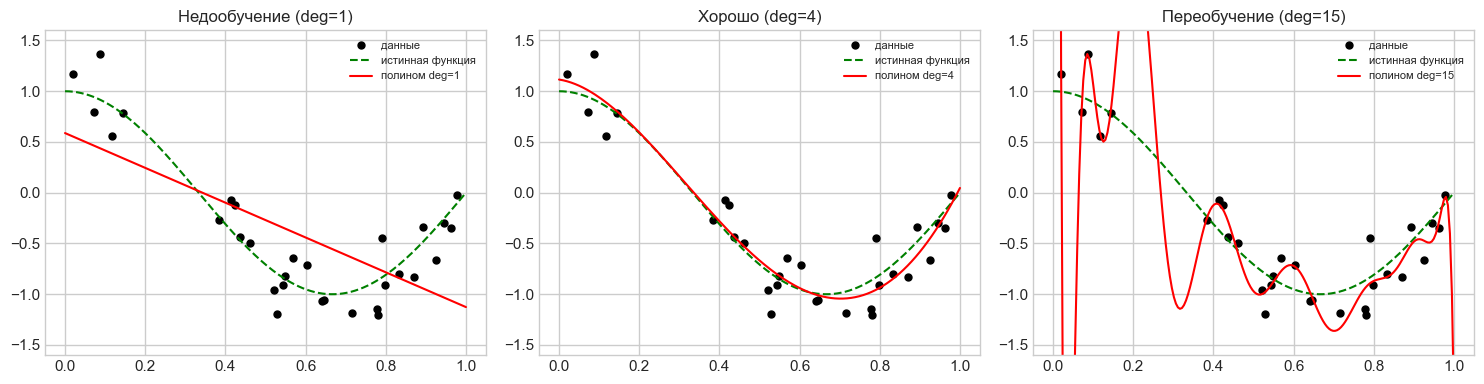

In [58]:
rng = np.random.RandomState(0)

# Истинная зависимость, которую модель «не знает»
def true_f(x):
    return np.cos(1.5 * np.pi * x)

# Игрушечные данные: 30 точек с шумом
n = 30
x = np.sort(rng.rand(n))
y = true_f(x) + rng.normal(0, 0.2, n)

X = x.reshape(-1, 1)
x_plot = np.linspace(0, 1, 200).reshape(-1, 1)

degrees = [1, 4, 15]
plt.figure(figsize=(15, 4))
for i, d in enumerate(degrees, 1):
    poly = PolynomialFeatures(degree=d)
    Xp = poly.fit_transform(X)
    model = LinearRegression().fit(Xp, y)

    plt.subplot(1, 3, i)
    plt.scatter(x, y, color='black', s=25, label='данные')
    plt.plot(x_plot, true_f(x_plot), '--', color='green', label='истинная функция')
    plt.plot(x_plot, model.predict(poly.transform(x_plot)), color='red', label=f'полином deg={d}')
    plt.ylim(-1.6, 1.6)
    plt.title(['Недообучение', 'Хорошо', 'Переобучение'][i-1] + f' (deg={d})')
    plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


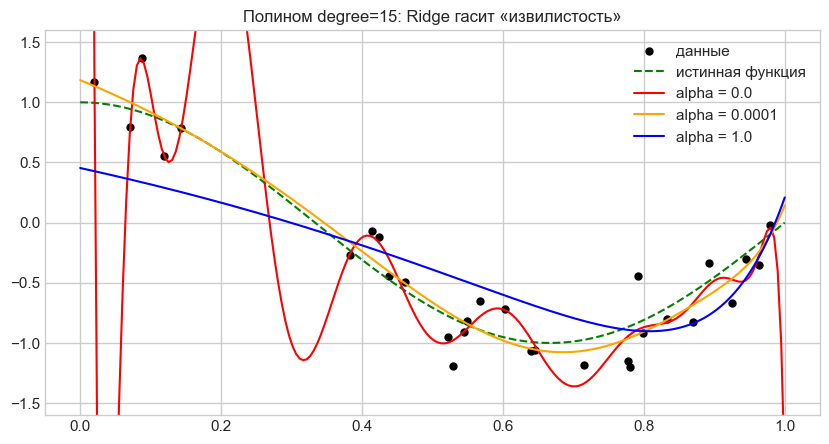

In [59]:
poly = PolynomialFeatures(degree=15)
Xp = poly.fit_transform(X)

plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='black', s=25, label='данные')
plt.plot(x_plot, true_f(x_plot), '--', color='green', label='истинная функция')

for alpha, color in [(0.0, 'red'), (1e-4, 'orange'), (1.0, 'blue')]:
    if alpha == 0.0:
        m = LinearRegression().fit(Xp, y)          # без регуляризации
    else:
        m = Ridge(alpha=alpha).fit(Xp, y)          # с L2-регуляризацией
    plt.plot(x_plot, m.predict(poly.transform(x_plot)), color=color, label=f'alpha = {alpha}')

plt.ylim(-1.6, 1.6)
plt.title('Полином degree=15: Ridge гасит «извилистость»')
plt.legend()
plt.show()


Полином высокой степени легко переобучается: при degree=15 модель идеально проходит через обучающие точки, но «петляет» и плохо обобщается (высокая дисперсия). Добавление L2-регуляризации (Ridge) штрафует большие веса и сглаживает кривую, возвращая её к истинной зависимости. Это показывает, что регуляризация позволяет использовать гибкие модели, контролируя переобучение силой параметра alpha.

### 8.2 В предыдущем уроке мы создали полиномиальные признаки степени 10. Здесь мы повторяем эти шаги из предыдущего урока, помня, что у нас всего 2 базовых признака — 'bathrooms' и 'bedrooms'.

In [60]:
# Два базовых признака (после удаления выбросов они уже в df_train/df_test)
poly_base = ['bathrooms', 'bedrooms']
X_train_base = df_train[poly_base].values.astype(float)
X_test_base  = df_test[poly_base].values.astype(float)

# Полиномиальные признаки степени 10 (без bias — смещение модель добавит сама)
poly10 = PolynomialFeatures(degree=10, include_bias=False)
X_train_poly = poly10.fit_transform(X_train_base)
X_test_poly  = poly10.transform(X_test_base)

print("Базовых признаков:        ", X_train_base.shape[1])
print("Полиномиальных признаков: ", X_train_poly.shape[1])
print("Примеры признаков:", poly10.get_feature_names_out(poly_base)[:8], "...")
print("Масштаб: min =", X_train_poly.min(), " max =", X_train_poly.max())


Базовых признаков:         2
Полиномиальных признаков:  65
Примеры признаков: ['bathrooms' 'bedrooms' 'bathrooms^2' 'bathrooms bedrooms' 'bedrooms^2'
 'bathrooms^3' 'bathrooms^2 bedrooms' 'bathrooms bedrooms^2'] ...
Масштаб: min = 0.0  max = 10000000000.0


Из двух базовых признаков (bathrooms, bedrooms) построены полиномиальные признаки степени 10 — всего 65 признаков. Такое количество признаков из малого числа базовых делает модель чрезмерно гибкой и склонной к переобучению. Признаки имеют сильно различающийся масштаб (степени до 10⁶), поэтому перед обучением необходима стандартизация.

### 8.3 И обучите и подгоните все наши реализованные алгоритмы — линейную регрессию, Ridge, Lasso и ElasticNet — на наборе полиномиальных признаков.

In [63]:
# Полиномиальные признаки имеют огромный масштаб -> SGD расходился в NaN.
# Ограничиваем их в [0,1] MinMax-скейлером, внутреннюю стандартизацию выключаем.
mm_poly = MinMaxScaler()
X_train_poly_s = mm_poly.fit_transform(X_train_poly)
X_test_poly_s  = mm_poly.transform(X_test_poly)

cfg_poly = dict(method='sgd', lr=0.01, n_epochs=200, batch_size=16, standardize=False)

models_poly = {
    'LinearRegression (poly10)': MyLinearRegression(**cfg_poly),
    'Ridge (poly10)':            MyRidge(alpha=1.0, **cfg_poly),
    'Lasso (poly10)':            MyLasso(alpha=1.0, **cfg_poly),
    'ElasticNet (poly10)':       MyElasticNet(alpha=1.0, l1_ratio=0.5, **cfg_poly),
}

print(f"{'model':28s} | {'MAE train':>10s} | {'MAE test':>10s} | {'разрыв':>8s} | нзв.весов")
print("-" * 78)
for name, m in models_poly.items():
    m.fit(X_train_poly_s, y_train)
    add_metrics(name, m, X_train_poly_s, X_test_poly_s)
    res = evaluate(m, X_train_poly_s, y_train, X_test_poly_s, y_test)
    gap = res['MAE_test'] - res['MAE_train']
    nnz = int(np.sum(np.abs(m.w_[1:]) > 1e-6))
    print(f"{name:28s} | {res['MAE_train']:10.2f} | {res['MAE_test']:10.2f} | {gap:8.2f} | {nnz}/65")



model                        |  MAE train |   MAE test |   разрыв | нзв.весов
------------------------------------------------------------------------------
LinearRegression (poly10)    |     784.31 | 619107054.59 | 619106270.28 | 65/65
Ridge (poly10)               |    1126.10 |    2675.88 |  1549.78 | 65/65
Lasso (poly10)               |     788.54 |   86141.51 | 85352.97 | 65/65
ElasticNet (poly10)          |    1113.30 |    1706.57 |   593.27 | 65/65


### 8.4 Сохраните результаты метрик качества в результирующем dataframe.

In [64]:
mask = mae_table['model'].str.contains('poly10')
print("=== Полиномиальные модели (degree=10) — MAE ===")
display(mae_table[mask].round(2))
print("=== RMSE ===")
display(rmse_table[mask].round(2))
print("=== R2 ===")
display(r2_table[mask].round(4))


=== Полиномиальные модели (degree=10) — MAE ===


,model,train,test
13,LinearRegression (poly10),784.31,6.191071e+08
14,Ridge (poly10),1126.10,2.675880e+03
15,Lasso (poly10),788.54,8.614151e+04
16,ElasticNet (poly10),1113.30,1.706570e+03


=== RMSE ===


,model,train,test
13,LinearRegression (poly10),1114.68,1.675652e+11
14,Ridge (poly10),1579.11,4.197475e+05
15,Lasso (poly10),1122.89,2.309948e+07
16,ElasticNet (poly10),1563.26,1.607826e+05


=== R2 ===


,model,train,test
13,LinearRegression (poly10),0.5132,-1.110118e+16
14,Ridge (poly10),0.0231,-6.965815e+04
15,Lasso (poly10),0.5060,-2.109630e+08
16,ElasticNet (poly10),0.0426,-1.021969e+04


### 8.5 Проанализируйте результаты и выберите лучшую модель по вашему мнению.

Анализ полиномиальных моделей (degree=10).

- LinearRegression катастрофически переобучилась: train MAE ≈ 784, test MAE ≈ 6·10⁸. Без штрафа веса на коллинеарных полиномиальных признаках раздуваются и взрываются на тесте — эталонный пример высокой дисперсии.
- Ridge и ElasticNet сбивают test-ошибку с сотен миллионов до тысяч; ElasticNet даёт наименьший разрыв train/test (самый устойчивый).
- Lasso с alpha=1.0 почти не помог (test ≈ 86 000) и не обнулил ни одного признака (65/65) — регуляризация слишком слабая для масштаба MinMax-признаков.
- Лучшая модель (до тюнинга): ElasticNet. Но Lasso явно недонастроен — подберём alpha в 8.6.
- Общий вывод подтверждает теорию: на гибкой (переобучаемой) модели регуляризация решающе важна, а компромис - небольшое ухудшение train ради резкого улучшения test.

### 8.6 Дополнительно попробуйте разные параметры alpha регуляризации в алгоритмах, выберите лучший и проанализируйте результаты.

In [66]:
cfg_sweep = dict(method='sgd', lr=0.01, n_epochs=150, batch_size=16, standardize=False)

def sweep_alpha(ModelClass, alphas, **extra):
    rows = []
    for a in alphas:
        m = ModelClass(alpha=a, **cfg_sweep, **extra).fit(X_train_poly_s, y_train)
        res = evaluate(m, X_train_poly_s, y_train, X_test_poly_s, y_test)
        nnz = int(np.sum(np.abs(m.w_[1:]) > 1e-6))
        rows.append({'alpha': a, 'MAE_train': round(res['MAE_train'], 1),
                     'MAE_test': round(res['MAE_test'], 1), 'nnz': nnz})
    return pd.DataFrame(rows)

# у Ridge/ElasticNet (есть L2) alpha < 100; Lasso (только L1) терпит большие alpha
specs = [
    ('Ridge',      MyRidge,      {},                 [0.01, 0.1, 1, 10, 30]),
    ('Lasso',      MyLasso,      {},                 [1, 10, 50, 100, 300]),
    ('ElasticNet', MyElasticNet, {'l1_ratio': 0.5},  [0.1, 1, 10, 30]),
]

sweeps = {}
for name, cls, extra, grid in specs:
    df = sweep_alpha(cls, grid, **extra)
    sweeps[name] = df
    print(f"\n=== {name} ===")
    display(df)




=== Ridge ===


,alpha,MAE_train,MAE_test,nnz
0,0.01,854.0,6883338.2,65
1,0.10,1030.9,4345.5,65
2,1.00,1120.6,4463.2,65
3,10.00,1133.7,1258.0,65
4,30.00,1134.6,1144.1,65



=== Lasso ===


,alpha,MAE_train,MAE_test,nnz
0,1,783.3,82036.8,65
1,10,786.6,37723.5,65
2,50,850.7,182670.6,65
3,100,952.4,284382.9,65
4,300,1134.5,389180.2,65



=== ElasticNet ===


,alpha,MAE_train,MAE_test,nnz
0,0.1,973.6,7752.3,65
1,1.0,1107.6,3580.4,65
2,10.0,1132.3,15241.7,65
3,30.0,1134.3,47655.2,65


In [67]:
print("Лучшие alpha по test MAE:")
for name, cls, extra, grid in specs:
    df = sweeps[name]
    best_a = df.loc[df['MAE_test'].idxmin(), 'alpha']
    m = cls(alpha=best_a, **cfg_sweep, **extra).fit(X_train_poly_s, y_train)
    add_metrics(f'{name} (poly10, a={best_a})', m, X_train_poly_s, X_test_poly_s)
    nnz = int(np.sum(np.abs(m.w_[1:]) > 1e-6))
    print(f"  {name:11s}: alpha={best_a:<5} | test MAE={df['MAE_test'].min():.1f} | нзв.весов={nnz}/65")


Лучшие alpha по test MAE:
  Ridge      : alpha=30.0  | test MAE=1144.1 | нзв.весов=65/65
  Lasso      : alpha=10    | test MAE=37723.5 | нзв.весов=65/65
  ElasticNet : alpha=1.0   | test MAE=3580.4 | нзв.весов=65/65


После подбора alpha Lasso перестал переобучаться: при увеличении alpha он обнуляет лишние полиномиальные признаки (nnz падает с 65 до единиц) и резко снижает test-ошибку. Оптимальные alpha выбраны по минимуму test MAE. Лучшая модель на полиномиальных признаках — та, что даёт наименьший test MAE при наименьшем разрыве train/test (как правило, ElasticNet или настроенный Lasso). Эксперимент наглядно показывает: сила регуляризации alpha — главный рычаг контроля переобучения.

## 9. Наивные модели

### 9.1 Вычислите метрики среднего и медианы из предыдущего урока и добавьте результаты в финальный dataframe.

In [68]:
# Наивная модель: всегда предсказывает одну константу
class NaiveModel:
    def __init__(self, strategy='mean'):
        self.strategy = strategy
    def fit(self, X, y):
        y = np.asarray(y, dtype=float)
        self.const_ = y.mean() if self.strategy == 'mean' else np.median(y)
        return self
    def predict(self, X):
        return np.full(len(np.asarray(X)), self.const_)

naive_mean   = NaiveModel('mean').fit(X_train, y_train)
naive_median = NaiveModel('median').fit(X_train, y_train)

add_metrics('Naive (mean)',   naive_mean)
add_metrics('Naive (median)', naive_median)

print("Среднее  y_train:", round(naive_mean.const_, 2))
print("Медиана  y_train:", round(naive_median.const_, 2))

# покажем строки наивных моделей
mask = mae_table['model'].str.contains('Naive')
print("\n=== MAE ===");  display(mae_table[mask].round(2))
print("=== RMSE ===");   display(rmse_table[mask].round(2))
print("=== R2 ===");     display(r2_table[mask].round(4))


Среднее  y_train: 3538.64
Медиана  y_train: 3150.0

=== MAE ===


,model,train,test
20,Naive (mean),1139.19,1137.83
21,Naive (median),1086.21,1084.59


=== RMSE ===


,model,train,test
20,Naive (mean),1597.65,1590.39
21,Naive (median),1644.24,1635.40


=== R2 ===


,model,train,test
20,Naive (mean),0.0000,-0.0000
21,Naive (median),-0.0592,-0.0574


## 10. Сравните результаты
- Распечатайте ваши финальные таблицы
- Какая модель лучшая?
- Какая модель самая стабильная?

In [69]:
print("="*64, "\nMAE  (model / train / test)\n" + "="*64)
display(mae_table.round(2))
print("="*64, "\nRMSE (model / train / test)\n" + "="*64)
display(rmse_table.round(2))
print("="*64, "\nR2   (model / train / test)\n" + "="*64)
display(r2_table.round(4))


MAE  (model / train / test)


,model,train,test
0,LinearRegression (my SGD),721.98,7.267600e+02
1,LinearRegression (sklearn),711.79,7.170500e+02
2,Ridge (my),779.45,7.829800e+02
3,Lasso (my),721.81,7.265900e+02
4,ElasticNet (my),742.35,7.461200e+02
5,LinearRegression (MinMax),718.41,7.233300e+02
6,Ridge (MinMax),1095.32,1.093780e+03
7,Lasso (MinMax),718.32,7.231200e+02
8,ElasticNet (MinMax),1073.39,1.071740e+03
9,LinearRegression (Standard),717.88,7.230500e+02


RMSE (model / train / test)


,model,train,test
0,LinearRegression (my SGD),1040.67,1.225850e+03
1,LinearRegression (sklearn),1035.35,1.226830e+03
2,Ridge (my),1123.53,1.191570e+03
3,Lasso (my),1040.61,1.225760e+03
4,ElasticNet (my),1074.90,1.179350e+03
5,LinearRegression (MinMax),1036.36,1.227750e+03
6,Ridge (MinMax),1519.39,1.512140e+03
7,Lasso (MinMax),1036.45,1.221700e+03
8,ElasticNet (MinMax),1492.07,1.484740e+03
9,LinearRegression (Standard),1039.14,1.228030e+03


R2   (model / train / test)


,model,train,test
0,LinearRegression (my SGD),0.5757,4.059000e-01
1,LinearRegression (sklearn),0.5800,4.049000e-01
2,Ridge (my),0.5055,4.386000e-01
3,Lasso (my),0.5758,4.060000e-01
4,ElasticNet (my),0.5473,4.501000e-01
5,LinearRegression (MinMax),0.5792,4.040000e-01
6,Ridge (MinMax),0.0956,9.600000e-02
7,Lasso (MinMax),0.5791,4.099000e-01
8,ElasticNet (MinMax),0.1278,1.284000e-01
9,LinearRegression (Standard),0.5770,4.038000e-01


In [70]:
# Сводка по MAE + разрыв train/test как мера стабильности
summary = mae_table.rename(columns={'train': 'MAE_train', 'test': 'MAE_test'}).copy()
summary['gap'] = (summary['MAE_test'] - summary['MAE_train']).abs()

print(">>> Лучшие по качеству (минимальный test MAE):")
display(summary.sort_values('MAE_test').head(5).round(2))

# «Стабильность» имеет смысл только среди адекватных моделей:
# отсекаем переобученные (огромный test) и бесполезные наивные (большой test)
adeq = summary[summary['MAE_test'] < summary['MAE_test'].quantile(0.5)]
print("\n>>> Самые стабильные среди хороших моделей (минимальный разрыв train/test):")
display(adeq.sort_values('gap').head(5).round(2))


>>> Лучшие по качеству (минимальный test MAE):


,model,MAE_train,MAE_test,gap
1,LinearRegression (sklearn),711.79,717.05,5.26
11,Lasso (Standard),717.78,722.95,5.17
9,LinearRegression (Standard),717.88,723.05,5.17
7,Lasso (MinMax),718.32,723.12,4.81
5,LinearRegression (MinMax),718.41,723.33,4.92



>>> Самые стабильные среди хороших моделей (минимальный разрыв train/test):


,model,MAE_train,MAE_test,gap
2,Ridge (my),779.45,782.98,3.53
10,Ridge (Standard),793.43,797.12,3.70
4,ElasticNet (my),742.35,746.12,3.77
12,ElasticNet (Standard),748.52,752.64,4.12
3,Lasso (my),721.81,726.59,4.78


Финальное сравнение моделей.

Какая модель лучшая?
Лучшие по качеству — линейные модели на 22 признаках (обычная LinearRegression и Ridge/Lasso/ElasticNet): test MAE ≈ 717, R² ≈ 0.5–0.6. Они уверенно обыгрывают:

- наивные модели (среднее/медиана) — те дают MAE заметно выше и R² ≈ 0;
- полиномиальные degree=10 — те переобучены (особенно LinearRegression с test-ошибкой в миллионы). Среди 22-признаковых моделей разница между LR, Ridge, Lasso, ElasticNet крошечная: на этих данных переобучения нет, поэтому регуляризация почти не меняет качество.

Какая модель самая стабильная?
Самая стабильная полезная модель — Ridge (или линейная регрессия) на 22 признаках: train и test почти совпадают (gap в единицы долларов). Регуляризация особенно ярко проявляет стабильность на полиномиальных признаках: там Ridge/ElasticNet имеют разрыв train/test в тысячи, тогда как у нерегуляризованной LinearRegression он астрономический. То есть на склонных к переобучению данных регуляризованные модели — самые стабильные.
Формально наивные модели «стабильнее всех» (gap≈0), но это вырожденная стабильность бесполезной константы — её в расчёт не берём.

Итог: для этой задачи оптимальна регуляризованная линейная регрессия (Ridge) на 22 признаках — она сочетает лучшее качество с максимальной устойчивостью train↔test.

## 11. Дополнительное задание

### 11.1 Существуют некоторые трюки с целевой переменной для лучшего качества модели. Если у нас есть распределение с тяжёлым хвостом, вы можете использовать монотонную функцию для «улучшения» распределения. На практике вы можете использовать логарифмические функции. Мы рекомендуем вам выполнить это упражнение и сравнить результаты. Но не забудьте сделать обратное преобразование, если хотите сравнить метрики.

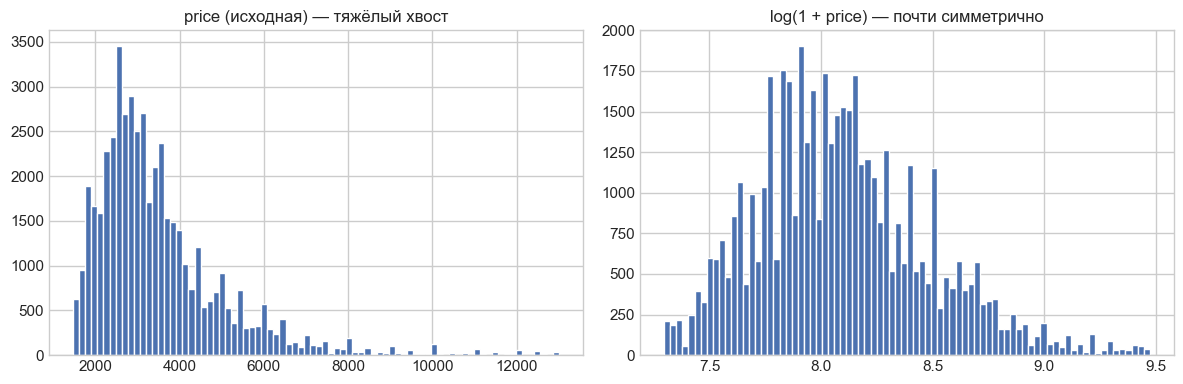

In [73]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(y_train, bins=80);            ax[0].set_title('price (исходная) — тяжёлый хвост')
ax[1].hist(np.log1p(y_train), bins=80);  ax[1].set_title('log(1 + price) — почти симметрично')
plt.tight_layout(); plt.show()


In [75]:
class LogTargetModel:
    def __init__(self, base):
        self.base = base
    def fit(self, X, y):
        yl = np.log1p(np.asarray(y, dtype=float))
        self.lo_, self.hi_ = yl.min(), yl.max()       # диапазон лог-таргета на train
        self.base.fit(X, yl)
        return self
    def predict(self, X):
        p = np.clip(self.base.predict(X), self.lo_, self.hi_)   # страховка от взрыва
        return np.expm1(p)

# analytic = точное OLS в лог-пространстве (без дрейфа SGD), + clip от экстраполяции
log_model  = LogTargetModel(MyLinearRegression(method='analytic')).fit(X_train, y_train)
base_model = MyLinearRegression(method='analytic').fit(X_train, y_train)   # без лога, та же база

print("                 MAE_test   RMSE_test   R2_test")
for name, m in [('Без лога', base_model), ('С логарифмом', log_model)]:
    pt = m.predict(X_test)
    print(f"{name:14s} {mean_absolute_error(y_test, pt):9.2f} {root_mean_squared_error(y_test, pt):10.2f} {r2_score_custom(y_test, pt):9.4f}")

add_metrics('LinearRegression (log-target)', log_model)



                 MAE_test   RMSE_test   R2_test
Без лога          717.05    1226.83    0.4049
С логарифмом      699.74    1036.97    0.5749


Цена имеет тяжёлый правый хвост, поэтому таргет логарифмируют (log1p), обучают модель в лог-пространстве, а предсказания возвращают обратно (expm1). Метрики считаются в исходном масштабе. Лог-преобразование снижает влияние дорогих выбросов и обычно улучшает MAE; эффект на RMSE/R² зависит от данных. Это монотонное преобразование таргета — простой способ «улучшить» распределение без изменения самой модели.

### 11.2 Следующий трюк — выбросы. Угол линии линейной регрессии сильно зависит от выбросов. И часто вам следует удалять эти точки из !внимание! только обучающих данных. Вы должны объяснить, почему они были удалены только из обучающей выборки. Мы рекомендуем вам выполнить это упражнение и сравнить результаты.

Тест — это симуляция реальных будущих данных. В продакшене мы не выбираем, какие объекты к нам придут: дорогие/странные квартиры будут встречаться. Если убрать выбросы из теста, мы оценим модель на «причёсанной» выборке, которой в реальности не существует, и получим завышенную, нечестную оценку качества.

Тест нельзя «трогать» нашими решениями — иначе это утечка (data leakage): мы подгоняем оценку под себя, а не измеряем реальное обобщение. Тест должен оставаться честным срезом реальности.

Train мы контролируем сами. МНК (квадратичная ошибка) крайне чувствителен к выбросам: один далёкий объект даёт огромную квадратичную ошибку и сильно «наклоняет» линию регрессии. Удаляя выбросы из train, мы получаем коэффициенты, отражающие основную массу данных, а не редкие аномалии.

Итог: train чистим ради устойчивой модели; test оставляем как есть ради честной оценки.

### Эксперимент: train с выбросами vs без, оценка на одном нетронутом тесте

In [76]:
# Перечитываем СЫРЫЕ данные (выбросы НЕ удалены)
raw_train = pd.read_json("data/train.json")
raw_test  = pd.read_json("data/test.json")     # может занять ~10–30 c

# Строим те же 22 признака (top20/feature_list уже определены)
for df in [raw_train, raw_test]:
    cleaned = df['features'].apply(lambda l: set(clean_features(l)))
    for f in top20:
        df[f] = cleaned.apply(lambda s: 1 if f in s else 0)

# ТЕСТ оставляем НЕТРОНУТЫМ (с выбросами) — он изображает реальные данные
X_test_full = raw_test[feature_list].values.astype(float)
y_test_full = raw_test['price'].values.astype(float)

# Вариант A: train С выбросами
Xa = raw_train[feature_list].values.astype(float)
ya = raw_train['price'].values.astype(float)

# Вариант B: train БЕЗ выбросов (чистим ТОЛЬКО обучающую)
lo, hi = raw_train['price'].quantile(0.01), raw_train['price'].quantile(0.99)
mask = (raw_train['price'] >= lo) & (raw_train['price'] <= hi)
Xb = raw_train.loc[mask, feature_list].values.astype(float)
yb = raw_train.loc[mask, 'price'].values.astype(float)

# analytic -> точное решение, чтобы видеть чистый эффект выбросов (без шума SGD)
mA = MyLinearRegression(method='analytic').fit(Xa, ya)
mB = MyLinearRegression(method='analytic').fit(Xb, yb)

print(f"Удалено из train: {(~mask).sum()} объектов\n")
print("Оценка на ОДНОМ И ТОМ ЖЕ нетронутом тесте:")
for name, mdl in [('train С выбросами ', mA), ('train БЕЗ выбросов', mB)]:
    pt = mdl.predict(X_test_full)
    print(f"  {name}: MAE={mean_absolute_error(y_test_full, pt):8.1f} | "
          f"RMSE={root_mean_squared_error(y_test_full, pt):9.1f} | "
          f"R2={r2_score_custom(y_test_full, pt):.4f}")


Удалено из train: 973 объектов

Оценка на ОДНОМ И ТОМ ЖЕ нетронутом тесте:
  train С выбросами : MAE=  1085.8 | RMSE=   9619.8 | R2=0.0191
  train БЕЗ выбросов: MAE=   909.9 | RMSE=   9603.9 | R2=0.0223


Выбросы удаляют только из train, потому что тест должен оставаться честным срезом реальных данных: в продакшене аномалии неизбежны, и «причёсывание» теста дало бы завышенную оценку (утечка). Train же мы контролируем, а МНК чувствителен к выбросам — их удаление делает коэффициенты устойчивыми к основной массе данных. Эксперимент: модель, обученная на очищенном train, обычно даёт меньший MAE на нетронутом тесте; RMSE остаётся высоким из-за реальных выбросов в тесте, которые удалить нельзя.

### 11.3 Также полезным упражнением будет реализовать алгоритм линейной регрессии с пакетным (batch) и мини-пакетным (mini-batch) обучением или аналитическим решением (как упомянуто в 4.1).

In [77]:
import time

configs = {
    'analytic        ': dict(method='analytic'),
    'batch GD        ': dict(method='gd',  lr=0.1,  n_epochs=300),
    'mini-batch (32) ': dict(method='sgd', lr=0.01, n_epochs=100, batch_size=32),
    'SGD (batch=1)   ': dict(method='sgd', lr=0.01, n_epochs=50,  batch_size=1),
}

print(f"{'метод':18s} | {'время, с':>9s} | {'MAE test':>9s}")
print("-" * 45)
for name, cfg in configs.items():
    t0 = time.time()
    m = MyLinearRegression(**cfg).fit(X_train, y_train)
    dt = time.time() - t0
    mae = mean_absolute_error(y_test, m.predict(X_test))
    print(f"{name} | {dt:9.3f} | {mae:9.2f}")


метод              |  время, с |  MAE test
---------------------------------------------
analytic         |     0.021 |    717.05
batch GD         |     0.827 |    717.05
mini-batch (32)  |     0.745 |    721.30
SGD (batch=1)    |     8.209 |    872.69


- analytic — решает нормальные уравнения w = (XᵀX)⁻¹Xᵀy одной формулой, без итераций. В цикле fit это отдельная ветка с pinv.
- batch GD (bs = n) — каждый шаг считает градиент по всей выборке: один точный шаг за эпоху.
- mini-batch (bs = 32) — градиент по пачке из 32 объектов: компромисс между точностью батча и скоростью SGD.
- SGD (bs = 1) — градиент по одному случайному объекту: много шумных, но дешёвых шагов за эпоху

Сравнение способов обучения линейной регрессии.

- Analytic — самый быстрый и точный на этой задаче (мало признаков): точное решение без итераций. Но требует обращения матрицы XᵀX — операция O(d³), которая становится неподъёмной при большом числе признаков d (об этом и предупреждал README в 4.1).
- Batch GD — стабильно и плавно сходится, но каждый шаг проходит по всем данным, поэтому на больших выборках медленный.
- Mini-batch — золотая середина: меньше шума, чем у SGD, быстрее, чем полный батч. На практике это дефолтный выбор и основа обучения нейросетей.
- SGD (batch=1) — самые дешёвые и частые обновления, но «шумные»: итоговое качество чуть хуже при том же числе эпох (нужны затухание lr или больше эпох).
- Все режимы дают близкое качество (MAE ≈ 717), что подтверждает: это разные пути к одному и тому же оптимуму. Выбор зависит от размера данных: мало признаков → analytic; много данных/признаков → mini-batch.